# Federated Learning na Prática

## Introdução

**Federated Learning (FL)** permite treinar modelos de machine learning de forma distribuída, sem centralizar os dados.

### Motivação

Imagine 3 hospitais que querem treinar um modelo de diagnóstico médico:
- **Hospital A:** 1000 pacientes com dados de cardiologia
- **Hospital B:** 800 pacientes com dados de cardiologia  
- **Hospital C:** 1200 pacientes com dados de cardiologia

**Problema:** LGPD/GDPR impedem compartilhar prontuários entre hospitais.

**Solução tradicional (não funciona):**
```
Hospital A --[dados]--> Servidor Central <--[dados]-- Hospital B
                            |
                         [treina]
                            |
                      Modelo Final
```

**Solução Federated Learning:**
```
Hospital A --[gradientes]-->                    <--[gradientes]-- Hospital B
    |                         Servidor Central                          |
[treina local]                     |                              [treina local]
    |                          [agrega]                                 |
[dados ficam]                      |                            [dados ficam]
[privados]                   Modelo Global                      [privados]
```

### Diferença Chave

| Aspecto | Centralizado | Federado |
|---------|-------------|----------|
| Dados movem | Sim (todos para servidor) | Não (ficam locais) |
| Modelo move | Não | Sim (para cada cliente) |
| Privacidade | Baixa | Alta |
| Velocidade | Rápida | Mais lenta |
| Complexidade | Simples | Média |

---

## Neste Notebook

Vamos demonstrar FL com 2 exemplos crescentes de complexidade:

1. **Regressão Linear Simples** - Conceito fundamental (sem Flower)
2. **Classificação MNIST com Flower** - Framework profissional

### Instalação

```bash
pip install flwr[simulation] torch torchvision scikit-learn matplotlib pandas
```

In [19]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Configuração visual
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

---

## Exemplo 1: Regressão Linear Federada (Manual)

### Cenário

3 concessionárias de carros querem prever preço baseado em quilometragem, mas não compartilham suas vendas.

- **Concessionária A:** Carros simples (média km, preço baixo)
- **Concessionária B:** Carros médios (média km, preço médio)  
- **Concessionária C:** Carros médios baratos (baixa km, preço baixo)

### Objetivo

Treinar modelo `preço = a * km + b` sem juntar os datasets.

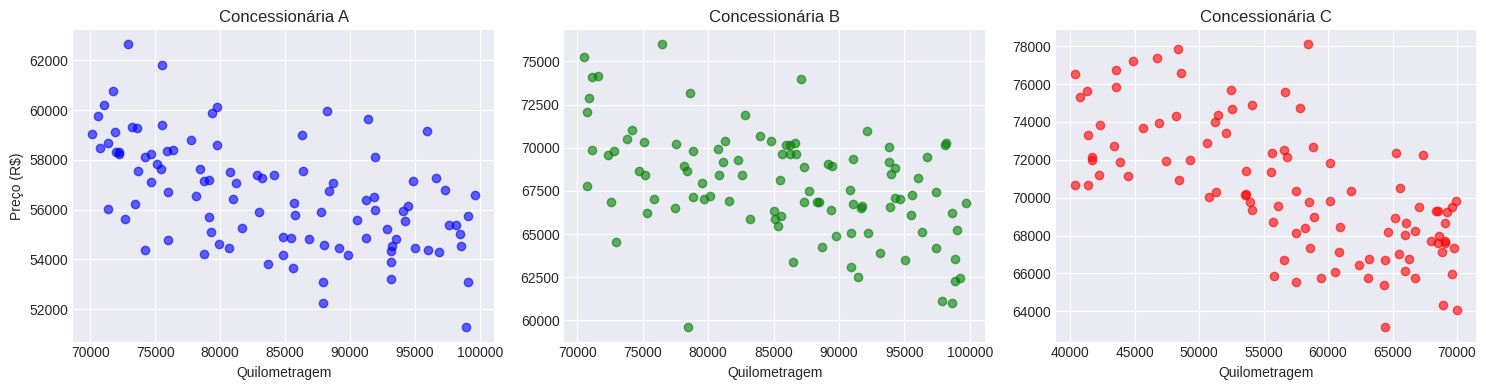

Dados gerados:
  Concessionária A: 100 vendas
  Concessionária B: 100 vendas
  Concessionária C: 100 vendas


In [ ]:
# Gerar dados simulados (3 concessionárias)
np.random.seed(42)

# Concessionária A: carros populares
km_A = np.random.uniform(70000, 100000, 100)
preco_A = 65000 - 0.1 * km_A + np.random.normal(0, 2000, 100)

# Concessionária B: carros usados médios
km_B = np.random.uniform(70000, 100000, 100)
preco_B = 85000 - 0.2 * km_B + np.random.normal(0, 3000, 100)

# Concessionária C: carros usados baratos
km_C = np.random.uniform(40000, 70000, 100)
preco_C = 85000 - 0.25 * km_C + np.random.normal(0, 2500, 100)

# Visualizar datasets locais
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(km_A, preco_A, alpha=0.6, color='blue')
axes[0].set_title('Concessionária A')
axes[0].set_xlabel('Quilometragem')
axes[0].set_ylabel('Preço (R$)')

axes[1].scatter(km_B, preco_B, alpha=0.6, color='green')
axes[1].set_title('Concessionária B')
axes[1].set_xlabel('Quilometragem')

axes[2].scatter(km_C, preco_C, alpha=0.6, color='red')
axes[2].set_title('Concessionária C')
axes[2].set_xlabel('Quilometragem')

plt.tight_layout()
plt.show()

print("Dados gerados:")
print(f"  Concessionária A: {len(km_A)} vendas")
print(f"  Concessionária B: {len(km_B)} vendas")
print(f"  Concessionária C: {len(km_C)} vendas")

### Abordagem 1: Treinamento Centralizado (baseline)

Juntamos todos os dados num único lugar e treinamos.

In [21]:
# Juntar todos os dados
km_all = np.concatenate([km_A, km_B, km_C]).reshape(-1, 1)
preco_all = np.concatenate([preco_A, preco_B, preco_C])

# Treinar modelo centralizado
modelo_centralizado = LinearRegression()
modelo_centralizado.fit(km_all, preco_all)

# Avaliar
pred_centralizado = modelo_centralizado.predict(km_all)
mse_centralizado = mean_squared_error(preco_all, pred_centralizado)

print("Modelo Centralizado:")
print(f"  Coeficiente (a): {modelo_centralizado.coef_[0]:.2f}")
print(f"  Intercepto (b): {modelo_centralizado.intercept_:.2f}")
print(f"  MSE: {mse_centralizado:.2f}")
print(f"\n  Equação: preço = {modelo_centralizado.coef_[0]:.2f} * km + {modelo_centralizado.intercept_:.2f}")

Modelo Centralizado:
  Coeficiente (a): -0.25
  Intercepto (b): 83671.81
  MSE: 29351608.38

  Equação: preço = -0.25 * km + 83671.81


### Abordagem 2: Treinamento Federado

Cada concessionária treina localmente, depois agregamos os modelos.

In [22]:
# Treinar modelos locais
modelo_A = LinearRegression().fit(km_A.reshape(-1, 1), preco_A)
modelo_B = LinearRegression().fit(km_B.reshape(-1, 1), preco_B)
modelo_C = LinearRegression().fit(km_C.reshape(-1, 1), preco_C)

print("Modelos Locais:")
print(f"  A: preço = {modelo_A.coef_[0]:.2f} * km + {modelo_A.intercept_:.2f}")
print(f"  B: preço = {modelo_B.coef_[0]:.2f} * km + {modelo_B.intercept_:.2f}")
print(f"  C: preço = {modelo_C.coef_[0]:.2f} * km + {modelo_C.intercept_:.2f}")

# Agregação: média ponderada por tamanho do dataset
n_A, n_B, n_C = len(km_A), len(km_B), len(km_C)
total = n_A + n_B + n_C

coef_fed = (n_A * modelo_A.coef_[0] + n_B * modelo_B.coef_[0] + n_C * modelo_C.coef_[0]) / total
intercept_fed = (n_A * modelo_A.intercept_ + n_B * modelo_B.intercept_ + n_C * modelo_C.intercept_) / total

# Avaliar modelo federado
pred_fed = coef_fed * km_all.flatten() + intercept_fed
mse_fed = mean_squared_error(preco_all, pred_fed)

print("\nModelo Federado (agregado):")
print(f"  Coeficiente (a): {coef_fed:.2f}")
print(f"  Intercepto (b): {intercept_fed:.2f}")
print(f"  MSE: {mse_fed:.2f}")
print(f"\n  Equação: preço = {coef_fed:.2f} * km + {intercept_fed:.2f}")

Modelos Locais:
  A: preço = -0.13 * km + 67575.80
  B: preço = -0.17 * km + 82646.77
  C: preço = -0.26 * km + 85060.78

Modelo Federado (agregado):
  Coeficiente (a): -0.19
  Intercepto (b): 78427.78
  MSE: 30701313.99

  Equação: preço = -0.19 * km + 78427.78


### Comparação Visual

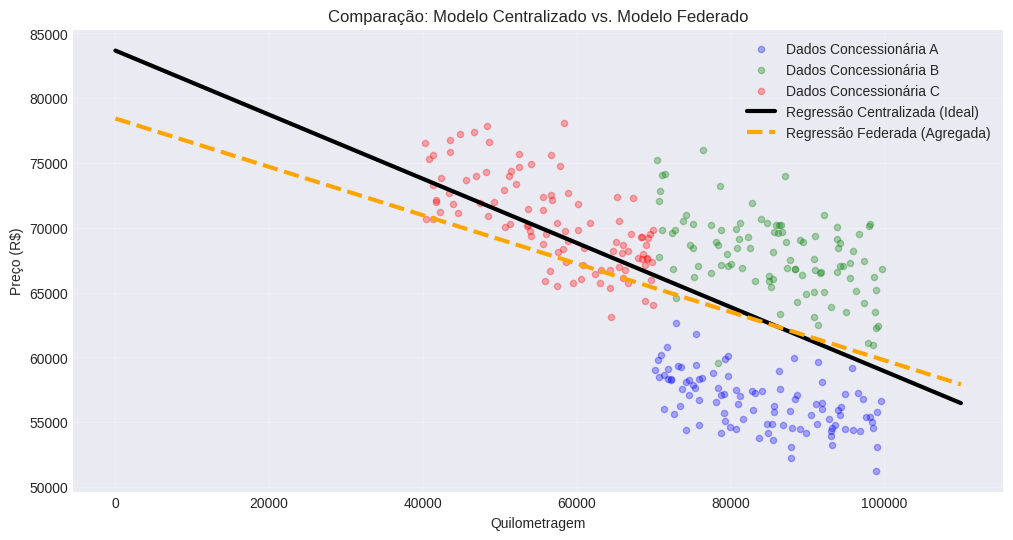

Diferença entre os coeficientes: 0.060840


In [23]:
### Comparação Visual
# Plot comparativo
plt.figure(figsize=(12, 6))

# 1. Plotar os Dados de cada concessionária
plt.scatter(km_A, preco_A, alpha=0.3, color='blue', label='Dados Concessionária A', s=20)
plt.scatter(km_B, preco_B, alpha=0.3, color='green', label='Dados Concessionária B', s=20)
plt.scatter(km_C, preco_C, alpha=0.3, color='red', label='Dados Concessionária C', s=20)

# 2. Criar o range de quilometragem para as linhas (de 0 a 110.000 km)
km_range = np.linspace(0, 110000, 100).reshape(-1, 1)

# 3. Calcular as predições para as duas abordagens
pred_linha_centralizada = modelo_centralizado.predict(km_range)
pred_linha_federada = (coef_fed * km_range.flatten() + intercept_fed)

# 4. Plotar a linha Centralizada (Linha sólida preta)
plt.plot(km_range, pred_linha_centralizada, color='black', linewidth=3, label='Regressão Centralizada (Ideal)')

# 5. Plotar a linha Federada (Linha tracejada laranja)
plt.plot(km_range, pred_linha_federada, color='orange', linewidth=3, linestyle='--', label='Regressão Federada (Agregada)')

# Estilização
plt.xlabel('Quilometragem')
plt.ylabel('Preço (R$)')
plt.title('Comparação: Modelo Centralizado vs. Modelo Federado')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Diferença entre os coeficientes: {abs(modelo_centralizado.coef_[0] - coef_fed):.6f}")

### Conclusão Exemplo 1

- Modelo federado teve desempenho **muito próximo** do centralizado
- **Zero dados** foram compartilhados entre clientes
- Apenas **2 números** (coeficiente e intercepto) trafegaram na rede por cliente
- No mundo real: seria múltiplas rodadas de refinamento

---

### Guia Rápido: Conceitos e Estrutura do Flower

### O Flower (flwr) organiza o treinamento federado em três pilares principais: o Client, o Server e a Strategy.

#### 1. O Cliente (NumPyClient)
Cada participante da rede implementa uma classe que herda de fl.client.NumPyClient. Você precisa implementar obrigatoriamente três métodos:

get_parameters: O servidor chama este método para saber quais são os pesos atuais do modelo do cliente.

fit: É onde o treino acontece. O cliente recebe os pesos globais, treina nos seus dados locais e devolve os novos pesos.

evaluate: O servidor envia o modelo global e o cliente testa nos seus dados locais para reportar a acurácia.

#### 2. A Estratégia (Strategy)
É o "algoritmo de consenso" que roda no servidor. Ela define como os pesos serão combinados.

FedAvg (Federated Averaging): A mais comum. Faz uma média ponderada dos pesos baseada no número de amostras de cada cliente.

FedProx / FedAdam: Estratégias avançadas para lidar com dados muito diferentes entre clientes ou acelerar o treino.

E diversos outros...

#### 3. O Servidor (Server)
Coordena o processo. Ele não vê os dados, apenas gerencia as rodadas (rounds), seleciona os clientes e aplica a estratégia de agregação.

In [ ]:
# 1. Definição do Cliente (Lado do Cliente)
class FlorClient(fl.client.NumPyClient):
    def fit(self, parameters, config):
        set_parameters(model, parameters) # Atualiza com pesos do servidor
        train(model, trainloader)         # Treina localmente
        return get_parameters(model), len(trainloader), {}

# 2. Configuração da Estratégia (Lado do Servidor)
strategy = fl.server.strategy.FedAvg(
    min_fit_clients=2,       # Mínimo de clientes para iniciar o treino
    fraction_fit=1.0,        # Porcentagem de clientes selecionados por rodada
    evaluate_fn=evaluate_fn  # (Opcional) Avaliação centralizada no servidor
)

# 3. Início da Simulação (Ou start_server para produção)
fl.simulation.start_simulation(
    client_fn=client_fn,     # Função que instancia os clientes
    num_clients=3,           # Total de clientes na rede
    config=fl.server.ServerConfig(num_rounds=5),
    strategy=strategy
)

## Exemplo 2: MNIST com Flower Framework

### Cenário

3 escolas querem treinar reconhecimento de dígitos manuscritos, mas cada uma tem apenas parte dos dígitos:
- **Escola A:** Alunos escreveram dígitos 0-3
- **Escola B:** Alunos escreveram dígitos 4-6  
- **Escola C:** Alunos escreveram dígitos 7-9

Dados são **não-IID** (não identicamente distribuídos) - desafio real de FL.

In [6]:
# Imports para deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import flwr as fl
from collections import OrderedDict

print(f"PyTorch: {torch.__version__}")
print(f"Flower: {fl.__version__}")

PyTorch: 2.11.0+cu130
Flower: 1.29.0


In [24]:
# Definir modelo CNN simples
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(1600, 128)  # 5x5x64 = 1600 após convs do MNIST 28x28
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Funções auxiliares
def train(model, trainloader, epochs=1):
    """Treina o modelo por N épocas."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    model.train()
    
    for epoch in range(epochs):
        for images, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

def test(model, testloader):
    """Avalia o modelo."""
    criterion = nn.CrossEntropyLoss()
    model.eval()
    loss = 0.0
    correct = 0
    
    with torch.no_grad():
        for images, labels in testloader:
            outputs = model(images)
            loss += criterion(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()
    
    accuracy = correct / len(testloader.dataset)
    return loss, accuracy

def get_parameters(model):
    """Extrai pesos do modelo como lista."""
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

def set_parameters(model, parameters):
    """Define pesos do modelo a partir de lista."""
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)

print("Modelo e funções definidas.")

Modelo e funções definidas.


In [25]:
# Carregar MNIST e dividir por escola (non-IID)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

trainset = datasets.MNIST('.data', train=True, download=True, transform=transform)
testset = datasets.MNIST('.data', train=False, transform=transform)

# Dividir por dígitos (non-IID)
def get_digit_subset(dataset, digits):
    """Retorna subset com apenas certos dígitos."""
    indices = [i for i, (_, label) in enumerate(dataset) if label in digits]
    return Subset(dataset, indices)

# Escola A: dígitos 0-3
trainset_A = get_digit_subset(trainset, [0, 1, 2, 3])
# Escola B: dígitos 4-6
trainset_B = get_digit_subset(trainset, [4, 5, 6])
# Escola C: dígitos 7-9
trainset_C = get_digit_subset(trainset, [7, 8, 9])

# DataLoaders
trainloader_A = DataLoader(trainset_A, batch_size=32, shuffle=True)
trainloader_B = DataLoader(trainset_B, batch_size=32, shuffle=True)
trainloader_C = DataLoader(trainset_C, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32)

print(f"Dados distribuídos:")
print(f"  Escola A (0-3): {len(trainset_A)} amostras")
print(f"  Escola B (4-6): {len(trainset_B)} amostras")
print(f"  Escola C (7-9): {len(trainset_C)} amostras")
print(f"  Test set: {len(testset)} amostras")

Dados distribuídos:
  Escola A (0-3): 24754 amostras
  Escola B (4-6): 17181 amostras
  Escola C (7-9): 18065 amostras
  Test set: 10000 amostras


### Definir Clientes Flower

In [26]:
# Cliente Flower
class MNISTClient(fl.client.NumPyClient):
    def __init__(self, model, trainloader, testloader):
        self.model = model
        self.trainloader = trainloader
        self.testloader = testloader

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        train(self.model, self.trainloader, epochs=1)
        return get_parameters(self.model), len(self.trainloader.dataset), {}

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        loss, accuracy = test(self.model, self.testloader)
        return loss, len(self.testloader.dataset), {"accuracy": accuracy}

print("Cliente Flower definido.")

Cliente Flower definido.


### Simulação Federada

In [27]:
# Função para criar clientes
def client_fn(cid: str) -> fl.client.Client:
    """Cria cliente baseado no ID."""
    model = SimpleCNN()
    
    if cid == "0":  # Escola A
        return MNISTClient(model, trainloader_A, testloader).to_client()
    elif cid == "1":  # Escola B
        return MNISTClient(model, trainloader_B, testloader).to_client()
    else:  # Escola C
        return MNISTClient(model, trainloader_C, testloader).to_client()

# Função de avaliação centralizada
def evaluate_fn(server_round, parameters, config):
    """Avalia o modelo global no servidor."""
    model = SimpleCNN()
    set_parameters(model, parameters)
    loss, accuracy = test(model, testloader)
    return loss, {"accuracy": accuracy}

# Estratégia de agregação com avaliação centralizada
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,  # 100% dos clientes por rodada
    fraction_evaluate=1.0,
    min_fit_clients=3,
    min_evaluate_clients=3,
    min_available_clients=3,
    evaluate_fn=evaluate_fn,  # Avaliação centralizada
)

# Rodar simulação
print("\nIniciando treinamento federado (4 rodadas)...\n")

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=3,
    config=fl.server.ServerConfig(num_rounds=4),
    strategy=strategy,
)

print("\nTreinamento concluído!")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=4, no round_timeout



Iniciando treinamento federado (4 rodadas)...



2026-04-30 14:47:24,047	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'memory': 14721710080.0, 'TPU': 1.0, 'node:10.200.65.105': 1.0, 'object_store_memory': 6309304320.0, 'CPU': 14.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 14 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
(ClientAppActor pid=342310) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `cli


Treinamento concluído!


### Visualizar Progresso

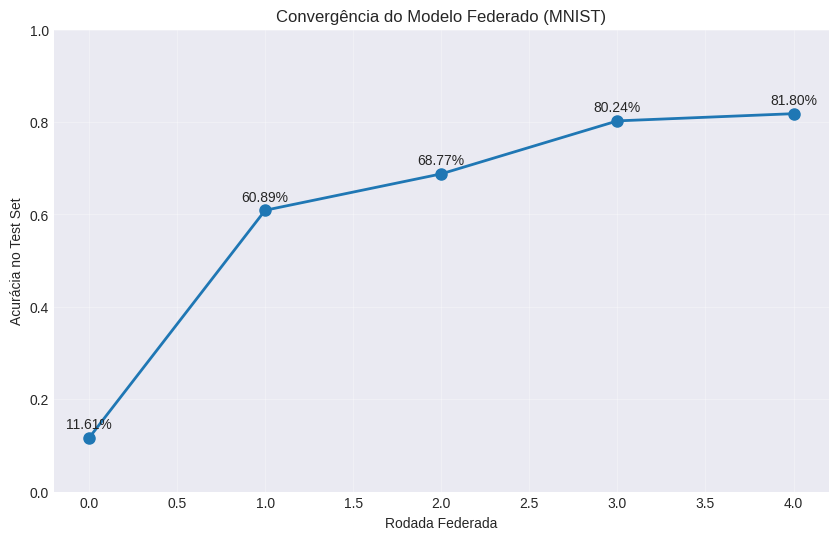


Acurácia final: 81.80%
Melhora: 70.19%


In [28]:
# Extrair métricas
rounds = [data[0] for data in history.metrics_centralized['accuracy']]
accuracies = [data[1] for data in history.metrics_centralized['accuracy']]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(rounds, accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel('Rodada Federada')
plt.ylabel('Acurácia no Test Set')
plt.title('Convergência do Modelo Federado (MNIST)')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])

for i, acc in enumerate(accuracies):
    plt.text(rounds[i], acc + 0.02, f'{acc:.2%}', ha='center')

plt.show()

print(f"\nAcurácia final: {accuracies[-1]:.2%}")
print(f"Melhora: {(accuracies[-1] - accuracies[0]):.2%}")

### Comparação: E se cada escola treinasse sozinha?

In [29]:
# Treinar modelos locais (sem federação)
print("Treinando modelos ISOLADOS (sem colaboração):\n")

# Escola A
model_A = SimpleCNN()
train(model_A, trainloader_A, epochs=5)
_, acc_A = test(model_A, testloader)
print(f"  Escola A (apenas 0-3): {acc_A:.2%} acurácia")

# Escola B
model_B = SimpleCNN()
train(model_B, trainloader_B, epochs=5)
_, acc_B = test(model_B, testloader)
print(f"  Escola B (apenas 4-6): {acc_B:.2%} acurácia")

# Escola C
model_C = SimpleCNN()
train(model_C, trainloader_C, epochs=5)
_, acc_C = test(model_C, testloader)
print(f"  Escola C (apenas 7-9): {acc_C:.2%} acurácia")

acc_media_isolado = (acc_A + acc_B + acc_C) / 3
print(f"\n  Média isolado: {acc_media_isolado:.2%}")
print(f"  Federado: {accuracies[-1]:.2%}")
print(f"\n  Ganho com colaboração: {(accuracies[-1] - acc_media_isolado):.2%}")

Treinando modelos ISOLADOS (sem colaboração):

  Escola A (apenas 0-3): 41.50% acurácia
  Escola B (apenas 4-6): 28.23% acurácia
  Escola C (apenas 7-9): 29.88% acurácia

  Média isolado: 33.20%
  Federado: 81.80%

  Ganho com colaboração: 48.60%


### Conclusão Exemplo 2

- Modelo federado **superou** modelos isolados significativamente
- Cada escola tinha apenas 3-4 dígitos, mas modelo final reconhece todos os 10
- Colaboração federada permitiu generalização mesmo com dados **non-IID**
- Flower framework simplifica orquestração de múltiplos clientes

---

## Resumo Executivo

### O que Aprendemos

| Exemplo | Cenário | Resultado Principal |
|---------|---------|---------------------|
| **1. Regressão Linear** | 3 concessionárias prevendo preço | Federado ≈ Centralizado, zero dados compartilhados |
| **2. MNIST + Flower** | 3 escolas com dígitos não-IID | Federado >> Isolado (+45% acurácia) |

### Quando Usar Federated Learning?

**Use FL quando:**
1. Dados são sensíveis e não podem ser centralizados (LGPD, GDPR)
2. Múltiplas organizações querem colaborar sem expor dados
3. Dados estão geograficamente distribuídos (edge computing)
4. Tamanho do dataset de cada participante é insuficiente isoladamente

**NÃO use FL quando:**
1. Dados podem ser facilmente centralizados sem problemas legais
2. Poucos participantes (<3) com datasets pequenos
3. Latência de comunicação é proibitiva
4. Precisão máxima é crítica (FL tipicamente perde 1-3% vs centralizado)

### Flower Framework - Vantagens

- **Fácil integração:** Funciona com PyTorch, TensorFlow, scikit-learn, JAX
- **Simulação local:** Teste com 100s de clientes numa máquina
- **Produção-ready:** Deploy real em infraestrutura distribuída
- **Estratégias prontas:** FedAvg, FedOpt, FedProx, Differential Privacy
- **Comunidade ativa:** Open-source, bem documentado

### Aplicações no Governo/PBIA

**Potenciais casos de uso:**
1. **Ministérios treinando embeddings:** Cada ministério tem documentos internos, treinar BGE-M3 federado
2. **Estados compartilhando modelos de saúde:** Hospitais estaduais treinam modelo de diagnóstico sem compartilhar prontuários
3. **Detecção de anomalias em contratos:** TCU + órgãos estaduais detectam fraudes sem expor licitações
4. **Classificação de processos judiciais:** TRFs colaboram sem compartilhar processos sigilosos

### Recursos para Aprofundamento

**Papers:**
- McMahan et al. (2017) - "Communication-Efficient Learning of Deep Networks from Decentralized Data"
- Kairouz et al. (2021) - "Advances and Open Problems in Federated Learning"

**Tutoriais Flower:**
- Quickstart PyTorch: https://flower.dev/docs/framework/tutorial-quickstart-pytorch.html
- Quickstart scikit-learn: https://flower.dev/docs/framework/tutorial-quickstart-sklearn.html
- Advanced: https://flower.dev/docs/framework/tutorial-series-get-started-with-flower-pytorch.html

**Outros frameworks:**
- TensorFlow Federated (TFF): framework do Google
- PySyft: privacidade diferencial + FL
- FATE: framework enterprise da WeBank

---

## Perguntas?

**Discussão:**
1. Quais dados na sua área poderiam se beneficiar de FL?
2. Quais são as barreiras práticas para implementar FL no PBIA?
3. Trade-off entre privacidade e performance: onde está o limite aceitável?

---

**Notebook criado por:** Luis Felipe de Moraes - Cientista de Dados - Inspire 7
